In [13]:
import torch
import torchvision
import torch.nn as nn
from torchvision import transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
batch_size = 64
epochs = 10

In [4]:
train_dataset = torchvision.datasets.FashionMNIST(root='data', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = torchvision.datasets.FashionMNIST(root='data', train=False, transform=transforms.ToTensor())

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

In [7]:
class AlexNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1),  # 28x28
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),                 # 14x14

            nn.Conv2d(64, 192, kernel_size=3, padding=1),          # 14x14
            nn.BatchNorm2d(192),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                                     # 7x7

            nn.Conv2d(192, 384, kernel_size=3, padding=1),         # 7x7
            nn.BatchNorm2d(384),
            nn.ReLU(),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),         # 7x7
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),         # 7x7
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)                                      # 3x3
        )

        self.classifier = nn.Sequential(
            nn.Linear(256 * 3 * 3, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.classifier(x)
        return x


In [17]:
model = AlexNet()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
train_accuracies, train_losses = [], []

In [18]:
for epoch in range(epochs):
    correct = 0
    total = 0
    running_loss = 0.0

    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%')

Epoch [1/10], Loss: 0.4678, Accuracy: 83.19%
Epoch [2/10], Loss: 0.2941, Accuracy: 89.62%
Epoch [3/10], Loss: 0.2512, Accuracy: 90.99%
Epoch [4/10], Loss: 0.2232, Accuracy: 92.13%
Epoch [5/10], Loss: 0.1970, Accuracy: 92.98%
Epoch [6/10], Loss: 0.1760, Accuracy: 93.64%
Epoch [7/10], Loss: 0.1573, Accuracy: 94.33%
Epoch [8/10], Loss: 0.1404, Accuracy: 94.95%
Epoch [9/10], Loss: 0.1249, Accuracy: 95.46%
Epoch [10/10], Loss: 0.1138, Accuracy: 95.93%


In [20]:
with torch.no_grad():
    correct = 0
    total = len(test_loader.dataset)
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()

    acc = correct / total
    print(f'Accuracy of the model on the test images: {acc * 100:.2f}%')


Accuracy of the model on the test images: 92.48%


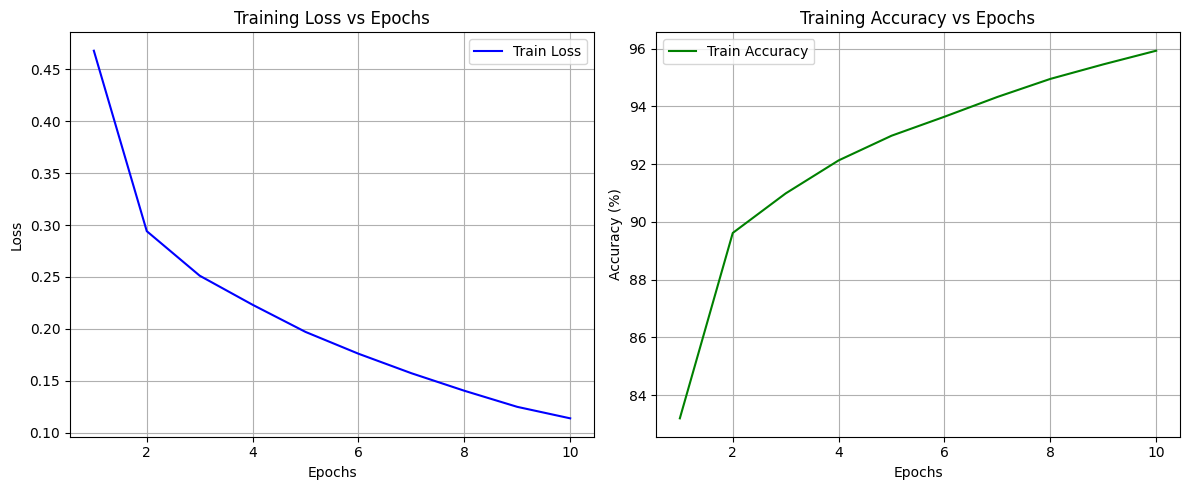

In [21]:
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss', color='blue')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss vs Epochs')
plt.grid(True)
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Train Accuracy', color='green')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Training Accuracy vs Epochs')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()